In [2]:
import os
import sys
import torch
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from pathlib import Path
import json
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add IndiaWeatherBench to path
sys.path.insert(0, '/burg-archive/home/mck2199/ML-Project/IndiaWeatherBench')

from india_benchmark.models.boundary_forcing_module import BoundaryForcingModule
from india_benchmark.models.networks.unet import Unet

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Create figures directory
figures_dir = Path('/burg-archive/home/mck2199/ML-Project/notebooks/figures/03_heatwave_analysis')
figures_dir.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Figures will be saved to: {figures_dir}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


Setup complete!
Figures will be saved to: /burg-archive/home/mck2199/ML-Project/notebooks/figures/03_heatwave_analysis
PyTorch version: 2.9.1+cu128
CUDA available: True


## 2. Load Model and Data


In [3]:
# Paths
checkpoint_path = "/burg-archive/home/mck2199/ML-Project/archive_baseline_unet/checkpoints/last.ckpt"
data_root = "/burg-archive/home/mck2199/ML-Project/data/indibench_h5_ori"
test_path = os.path.join(data_root, "test")
norm_params_path = os.path.join(data_root, "norm_params.json")

# Load normalization parameters
with open(norm_params_path, 'r') as f:
    norm_params = json.load(f)

# Get all test files
test_files = sorted(glob(os.path.join(test_path, "*.h5")))

# Parse dates
def parse_filename(filename):
    basename = os.path.basename(filename)
    date_str = basename.replace('.h5', '')
    return pd.to_datetime(date_str, format='%Y-%m-%d_%H')

test_dates = pd.DatetimeIndex([parse_filename(f) for f in test_files])

# Define heat wave period
heatwave_start = pd.Timestamp('2019-05-25')
heatwave_end = pd.Timestamp('2019-06-01')

# Find files in heat wave period
heatwave_mask = (test_dates >= heatwave_start) & (test_dates <= heatwave_end)
heatwave_files = [f for f, m in zip(test_files, heatwave_mask) if m]
heatwave_dates = test_dates[heatwave_mask]

print(f"Heat Wave Period: {heatwave_start.date()} to {heatwave_end.date()}")
print(f"Files found: {len(heatwave_files)}")
print(f"First file: {os.path.basename(heatwave_files[0])}")
print(f"Last file: {os.path.basename(heatwave_files[-1])}")
print(f"\nTotal timesteps: {len(heatwave_files)} (6-hourly)")


Heat Wave Period: 2019-05-25 to 2019-06-01
Files found: 29
First file: 2019-05-25_00.h5
Last file: 2019-06-01_00.h5

Total timesteps: 29 (6-hourly)


In [4]:
# Load the trained model
print("Loading trained UNet model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load checkpoint manually
checkpoint = torch.load(checkpoint_path, map_location=device)

# Define variables list
variables = ['TMP', 'UGRD', 'VGRD', 'PRMSL', 'HGT925', 'HGT850', 'HGT700', 'HGT600', 'HGT500', 'HGT250', 'HGT50',
             'TMP_prl925', 'TMP_prl850', 'TMP_prl700', 'TMP_prl600', 'TMP_prl500', 'TMP_prl250', 'TMP_prl50',
             'UGRD_prl925', 'UGRD_prl850', 'UGRD_prl700', 'UGRD_prl600', 'UGRD_prl500', 'UGRD_prl250', 'UGRD_prl50',
             'VGRD_prl925', 'VGRD_prl850', 'VGRD_prl700', 'VGRD_prl600', 'VGRD_prl500', 'VGRD_prl250', 'VGRD_prl50',
             'RH925', 'RH850', 'RH700', 'RH600', 'RH500', 'RH250', 'RH50']

# Instantiate the network
net = Unet(
    variables=variables,
    n_input_steps=2,
    hidden_channels=64,
    ch_mults=[1, 2, 4],
    mid_attn=False,
    n_blocks=2
)

# Instantiate the module
model = BoundaryForcingModule(
    net=net,
    img_size=[256, 256],
    boundary_pixels=10,
    variables=variables,
    vars_to_log=['TMP', 'UGRD', 'VGRD', 'PRMSL', 'HGT500', 'TMP_prl850', 'TMP_prl500', 
                 'UGRD_prl850', 'UGRD_prl500', 'VGRD_prl850', 'VGRD_prl500', 'RH850', 'RH700', 'RH500'],
    lr=2e-4,
    beta_1=0.9,
    beta_2=0.95,
    weight_decay=1e-5,
    warmup_epochs=10,
    max_epochs=100,
    warmup_start_lr=1e-8,
    eta_min=1e-8
)

# Load the state dict
model.load_state_dict(checkpoint['state_dict'], strict=False)
model.eval()
model.to(device)

print(f"✓ Model loaded successfully!")
print(f"  Device: {device}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")


Loading trained UNet model...
✓ Model loaded successfully!
  Device: cuda
  Total parameters: 36.1M


In [5]:
# Define spatial coordinates
lat_min, lat_max = 6.0, 36.72
lon_min, lon_max = 66.6, 97.25
grid_size = 256

lats = np.linspace(lat_min, lat_max, grid_size)
lons = np.linspace(lon_min, lon_max, grid_size)
lon_grid, lat_grid = np.meshgrid(lons, lats)

print("Spatial domain configured:"
)
print(f"  Grid size: {grid_size}×{grid_size}")
print(f"  Latitude: {lat_min}°N to {lat_max}°N")
print(f"  Longitude: {lon_min}°E to {lon_max}°E")


Spatial domain configured:
  Grid size: 256×256
  Latitude: 6.0°N to 36.72°N
  Longitude: 66.6°E to 97.25°E


## 3. Heat Wave Characterization

Let's analyze the temperature patterns during this period to understand the heat wave intensity and spatial extent.


In [6]:
# Load temperature data for all heat wave timesteps
print("Loading temperature data for heat wave period...")
heatwave_temps = []

for filepath in heatwave_files:
    with h5py.File(filepath, 'r') as f:
        temp_k = f['TMP'][()]
        temp_c = temp_k - 273.15  # Convert to Celsius
        heatwave_temps.append(temp_c)

heatwave_temps = np.array(heatwave_temps)

# Compute statistics
spatial_mean_temps = np.mean(heatwave_temps, axis=(1, 2))
spatial_max_temps = np.max(heatwave_temps, axis=(1, 2))
spatial_min_temps = np.min(heatwave_temps, axis=(1, 2))

# Overall statistics
overall_max_temp = np.max(spatial_max_temps)
overall_mean_temp = np.mean(spatial_mean_temps)
peak_day_idx = np.argmax(spatial_max_temps)
peak_day = heatwave_dates[peak_day_idx]

print(f"\nHeat Wave Temperature Statistics:")
print(f"  Overall max temperature: {overall_max_temp:.1f}°C")
print(f"  Overall mean temperature: {overall_mean_temp:.1f}°C")
print(f"  Peak temperature occurred: {peak_day.strftime('%Y-%m-%d %H:%M')}")
print(f"  Peak temperature value: {spatial_max_temps[peak_day_idx]:.1f}°C")
print(f"\nSpatial extent:")
print(f"  Mean of spatial maxima: {np.mean(spatial_max_temps):.1f}°C")
print(f"  Mean of spatial minima: {np.mean(spatial_min_temps):.1f}°C")


Loading temperature data for heat wave period...

Heat Wave Temperature Statistics:
  Overall max temperature: 48.4°C
  Overall mean temperature: 24.6°C
  Peak temperature occurred: 2019-05-29 02:00
  Peak temperature value: 48.4°C

Spatial extent:
  Mean of spatial maxima: 40.7°C
  Mean of spatial minima: -18.8°C


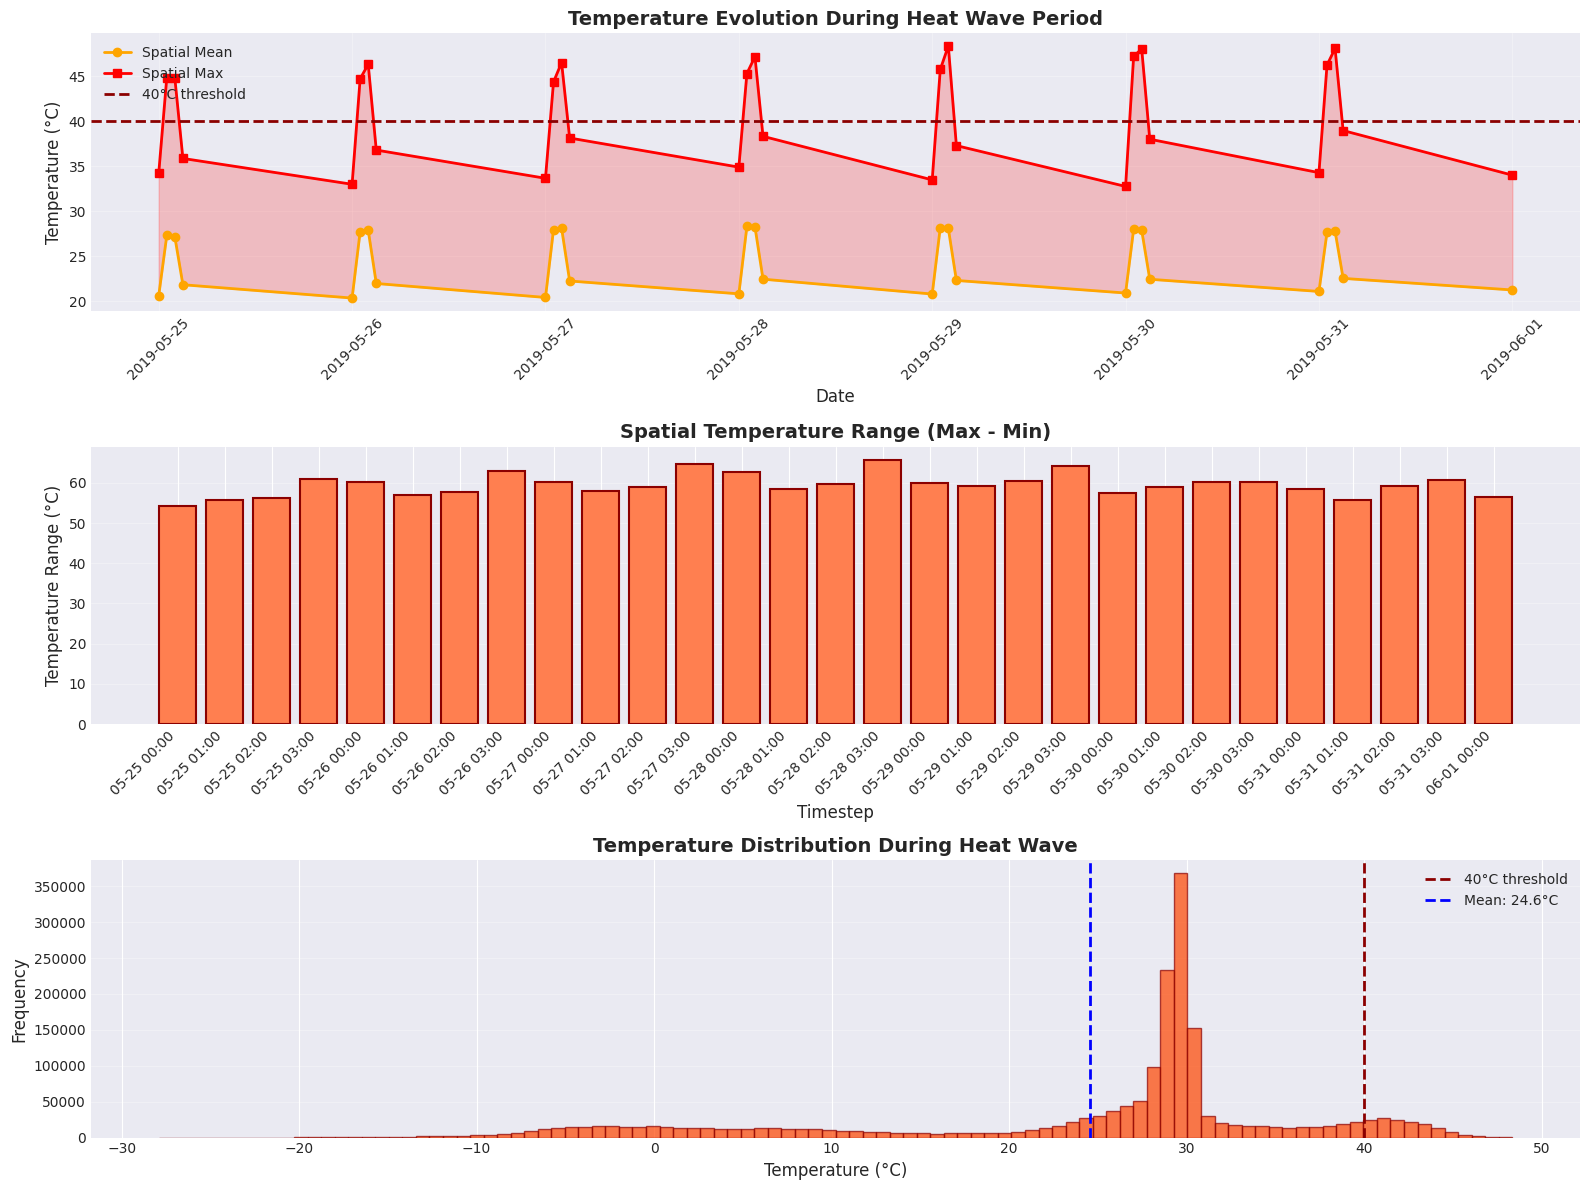


✓ Figure saved: 01_heatwave_temporal_evolution.png


In [7]:
# Visualize temperature evolution during heat wave
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Time series
axes[0].plot(heatwave_dates, spatial_mean_temps, 'o-', linewidth=2, markersize=6, label='Spatial Mean', color='orange')
axes[0].plot(heatwave_dates, spatial_max_temps, 's-', linewidth=2, markersize=6, label='Spatial Max', color='red')
axes[0].axhline(y=40, color='darkred', linestyle='--', linewidth=2, label='40°C threshold')
axes[0].fill_between(heatwave_dates, spatial_mean_temps, spatial_max_temps, alpha=0.2, color='red')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Temperature Evolution During Heat Wave Period', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Daily temperature range
temp_range = spatial_max_temps - spatial_min_temps
axes[1].bar(range(len(heatwave_dates)), temp_range, color='coral', edgecolor='darkred', linewidth=1.5)
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Temperature Range (°C)')
axes[1].set_title('Spatial Temperature Range (Max - Min)', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(heatwave_dates)))
axes[1].set_xticklabels([d.strftime('%m-%d %H:%M') for d in heatwave_dates], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

# Histogram of all temperatures during heat wave
axes[2].hist(heatwave_temps.flatten(), bins=100, alpha=0.7, color='orangered', edgecolor='darkred')
axes[2].axvline(x=40, color='darkred', linestyle='--', linewidth=2, label='40°C threshold')
axes[2].axvline(x=overall_mean_temp, color='blue', linestyle='--', linewidth=2, label=f'Mean: {overall_mean_temp:.1f}°C')
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Temperature Distribution During Heat Wave', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / '01_heatwave_temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: 01_heatwave_temporal_evolution.png")


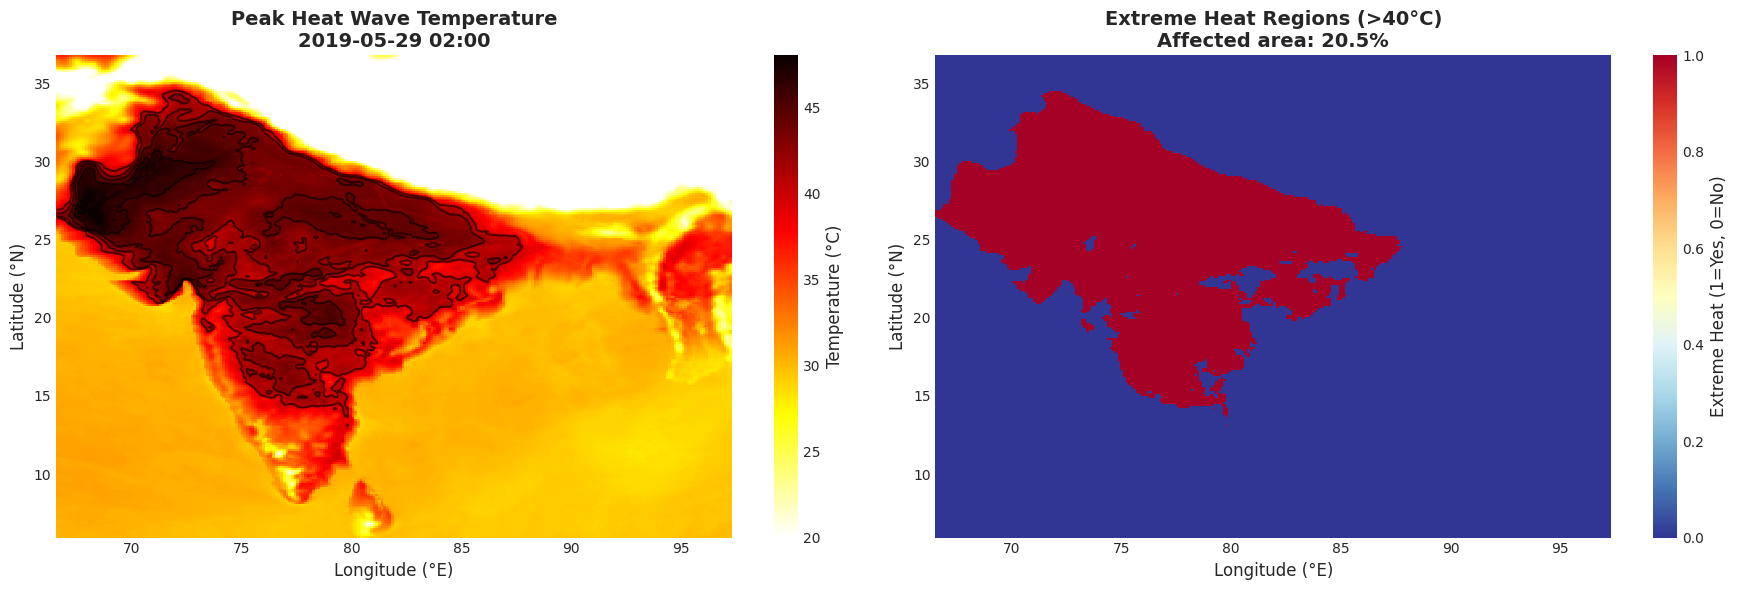

✓ Figure saved: 02_heatwave_spatial_extent.png

Extreme heat (>40°C) coverage:
  Number of grid points: 13422 / 65536
  Percentage of domain: 20.5%


In [8]:
# Visualize spatial patterns at peak heat wave time
peak_temp_map = heatwave_temps[peak_day_idx]

# Identify hottest regions (>40°C)
extreme_heat_mask = peak_temp_map > 40

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Peak temperature map
im0 = axes[0].pcolormesh(lon_grid, lat_grid, peak_temp_map, cmap='hot_r', shading='auto', vmin=20, vmax=48)
axes[0].contour(lon_grid, lat_grid, peak_temp_map, levels=[40, 42, 44, 46], colors='black', linewidths=1.5, alpha=0.6)
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Latitude (°N)')
axes[0].set_title(f'Peak Heat Wave Temperature\n{peak_day.strftime("%Y-%m-%d %H:%M")}', fontsize=14, fontweight='bold')
cbar0 = plt.colorbar(im0, ax=axes[0])
cbar0.set_label('Temperature (°C)')

# Extreme heat regions
im1 = axes[1].pcolormesh(lon_grid, lat_grid, extreme_heat_mask.astype(float), cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Latitude (°N)')
axes[1].set_title(f'Extreme Heat Regions (>40°C)\nAffected area: {100*np.sum(extreme_heat_mask)/extreme_heat_mask.size:.1f}%', 
                  fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[1])
cbar1.set_label('Extreme Heat (1=Yes, 0=No)')

plt.tight_layout()
plt.savefig(figures_dir / '02_heatwave_spatial_extent.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: 02_heatwave_spatial_extent.png")
print(f"\nExtreme heat (>40°C) coverage:")
print(f"  Number of grid points: {np.sum(extreme_heat_mask)} / {extreme_heat_mask.size}")
print(f"  Percentage of domain: {100*np.sum(extreme_heat_mask)/extreme_heat_mask.size:.1f}%")


## 4. Model Predictions During Heat Wave Peak


In [9]:
# Prediction function (from previous notebook)
def make_prediction(model, input_files, variables, norm_params, device):
    """Make a single step prediction given input files"""
    inputs = []
    for filepath in input_files:
        frame_data = []
        with h5py.File(filepath, 'r') as f:
            for var in variables:
                frame_data.append(f[var][()])
        inputs.append(np.stack(frame_data, axis=0))
    
    inputs = np.stack(inputs, axis=0)
    mean = np.array([norm_params['mean'][v] for v in variables])[:, None, None]
    std = np.array([norm_params['std'][v] for v in variables])[:, None, None]
    inputs_norm = (inputs - mean) / std
    inputs_tensor = torch.from_numpy(inputs_norm).float().unsqueeze(0).to(device)
    
    with torch.no_grad():
        prediction_norm = model.net(inputs_tensor)
    
    prediction = prediction_norm.cpu().numpy().squeeze() * std + mean
    return prediction.squeeze()

# Find peak heat wave index in full test set
peak_file = heatwave_files[peak_day_idx]
peak_file_idx = test_files.index(peak_file)

# Make sure we have 2 previous timesteps
if peak_file_idx >= 2:
    input_files = [test_files[peak_file_idx - 2], test_files[peak_file_idx - 1]]
    target_file = test_files[peak_file_idx]
    
    print(f"Generating prediction for peak heat wave:")
    print(f"  Target: {peak_day.strftime('%Y-%m-%d %H:%M')}")
    print(f"  Max temp (observed): {spatial_max_temps[peak_day_idx]:.1f}°C")
    print(f"  Input files: {os.path.basename(input_files[0])}, {os.path.basename(input_files[1])}")
    
    # Make prediction
    prediction = make_prediction(model, input_files, variables, norm_params, device)
    
    # Load ground truth
    with h5py.File(target_file, 'r') as f:
        ground_truth = np.stack([f[var][()] for var in variables], axis=0)
    
    print("✓ Prediction complete!")
else:
    print("Error: Not enough context for prediction")


Generating prediction for peak heat wave:
  Target: 2019-05-29 02:00
  Max temp (observed): 48.4°C
  Input files: 2019-05-29_00.h5, 2019-05-29_01.h5
✓ Prediction complete!


## 5. Peak Heat Wave: Prediction vs Ground Truth


Temperature Prediction Metrics (6h forecast):
  RMSE: 14.25°C
  MAE:  12.82°C
  Bias: -8.14°C
  Spatial Correlation: 0.502


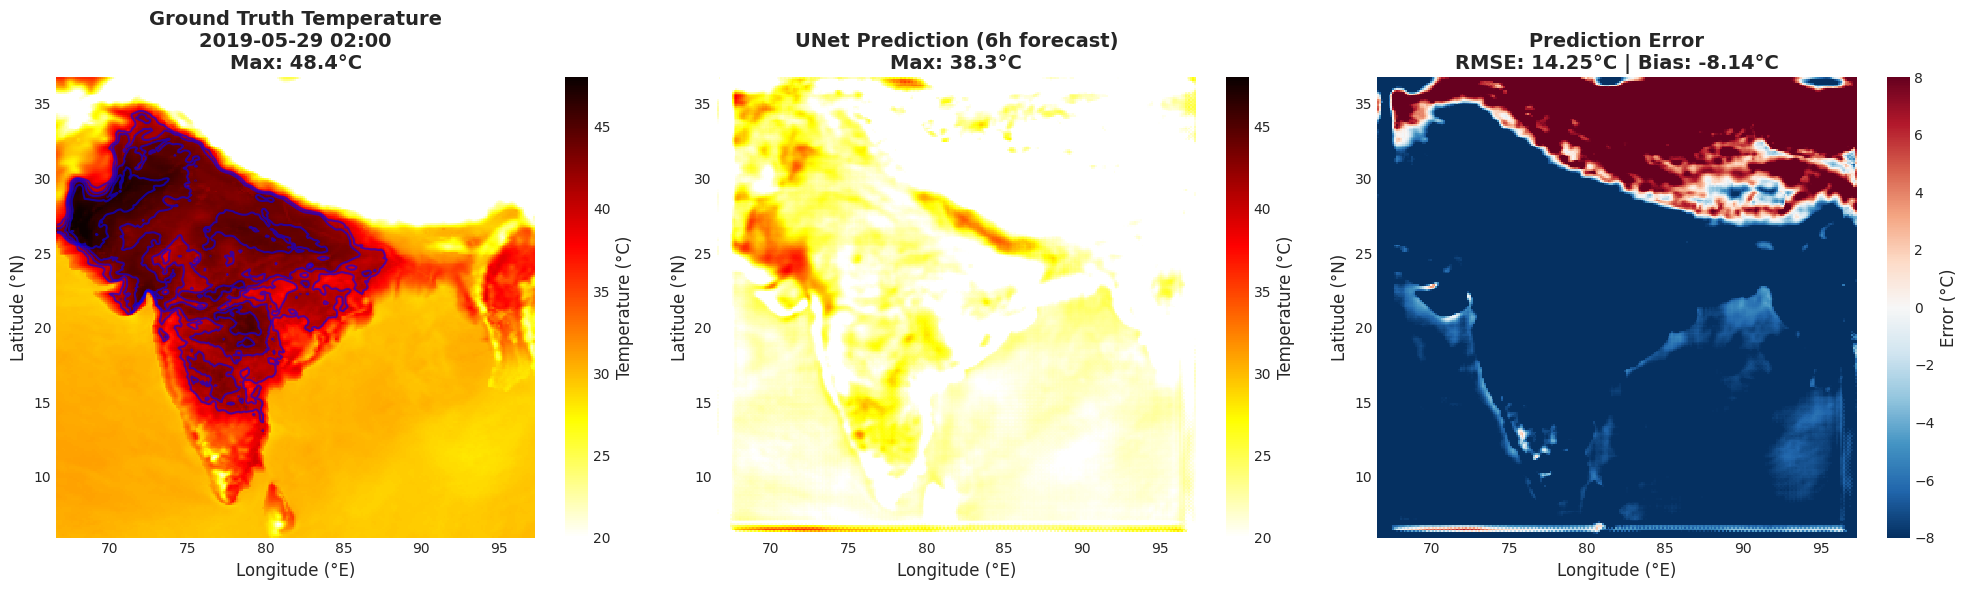

✓ Figure saved: 03_peak_heatwave_comparison.png


In [10]:
# Extract temperature
temp_idx = variables.index('TMP')
pred_temp = prediction[temp_idx] - 273.15
true_temp = ground_truth[temp_idx] - 273.15
error_temp = pred_temp - true_temp

# Calculate metrics
rmse_temp = np.sqrt(np.mean(error_temp**2))
mae_temp = np.mean(np.abs(error_temp))
bias_temp = np.mean(error_temp)

# Correlation
correlation = np.corrcoef(true_temp.flatten(), pred_temp.flatten())[0, 1]

print(f"Temperature Prediction Metrics (6h forecast):")
print(f"  RMSE: {rmse_temp:.2f}°C")
print(f"  MAE:  {mae_temp:.2f}°C")
print(f"  Bias: {bias_temp:.2f}°C")
print(f"  Spatial Correlation: {correlation:.3f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Ground Truth
im0 = axes[0].pcolormesh(lon_grid, lat_grid, true_temp, cmap='hot_r', shading='auto', vmin=20, vmax=48)
axes[0].contour(lon_grid, lat_grid, true_temp, levels=[40, 42, 44, 46], colors='blue', linewidths=1.5, alpha=0.6)
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Latitude (°N)')
axes[0].set_title(f'Ground Truth Temperature\n{peak_day.strftime("%Y-%m-%d %H:%M")}\nMax: {np.max(true_temp):.1f}°C', 
                  fontsize=14, fontweight='bold')
cbar0 = plt.colorbar(im0, ax=axes[0])
cbar0.set_label('Temperature (°C)')

# Prediction
im1 = axes[1].pcolormesh(lon_grid, lat_grid, pred_temp, cmap='hot_r', shading='auto', vmin=20, vmax=48)
axes[1].contour(lon_grid, lat_grid, pred_temp, levels=[40, 42, 44, 46], colors='blue', linewidths=1.5, alpha=0.6)
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Latitude (°N)')
axes[1].set_title(f'UNet Prediction (6h forecast)\nMax: {np.max(pred_temp):.1f}°C', 
                  fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[1])
cbar1.set_label('Temperature (°C)')

# Error
im2 = axes[2].pcolormesh(lon_grid, lat_grid, error_temp, cmap='RdBu_r', shading='auto', vmin=-8, vmax=8)
axes[2].set_xlabel('Longitude (°E)')
axes[2].set_ylabel('Latitude (°N)')
axes[2].set_title(f'Prediction Error\nRMSE: {rmse_temp:.2f}°C | Bias: {bias_temp:.2f}°C', 
                  fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[2])
cbar2.set_label('Error (°C)')

plt.tight_layout()
plt.savefig(figures_dir / '03_peak_heatwave_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: 03_peak_heatwave_comparison.png")


## 6. Multi-Lead Time Forecasts During Peak Heat Wave


In [11]:
# Multi-step prediction function
def make_autoregressive_predictions(model, initial_files, n_steps, variables, norm_params, device):
    """Make multi-step predictions using autoregressive forecasting."""
    predictions = []
    current_inputs = []
    
    for filepath in initial_files:
        frame_data = []
        with h5py.File(filepath, 'r') as f:
            for var in variables:
                frame_data.append(f[var][()])
        current_inputs.append(np.stack(frame_data, axis=0))
    
    mean = np.array([norm_params['mean'][v] for v in variables])[:, None, None]
    std = np.array([norm_params['std'][v] for v in variables])[:, None, None]
    
    for step in range(n_steps):
        inputs = np.stack(current_inputs, axis=0)
        inputs_norm = (inputs - mean) / std
        inputs_tensor = torch.from_numpy(inputs_norm).float().unsqueeze(0).to(device)
        
        with torch.no_grad():
            prediction_norm = model.net(inputs_tensor)
        
        prediction = prediction_norm.cpu().numpy().squeeze() * std + mean
        prediction = prediction.squeeze()
        predictions.append(prediction)
        current_inputs = [current_inputs[1], prediction]
    
    return predictions

# Generate predictions at 6h, 12h, 18h, 24h
if peak_file_idx >= 2 and peak_file_idx + 3 < len(test_files):
    print("Generating multi-step forecasts for peak heat wave day...")
    
    predictions_list = make_autoregressive_predictions(
        model, input_files, n_steps=4, variables=variables, 
        norm_params=norm_params, device=device
    )
    
    # Store with labels
    lead_times = ['6h', '12h', '18h', '24h']
    predictions_multi = {lt: pred for lt, pred in zip(lead_times, predictions_list)}
    
    # Load ground truths
    ground_truths_multi = {}
    for i, lt in enumerate(lead_times):
        with h5py.File(test_files[peak_file_idx + i], 'r') as f:
            ground_truths_multi[lt] = np.stack([f[var][()] for var in variables], axis=0)
    
    print("✓ Multi-step forecasts complete!")
    print(f"  Lead times: {', '.join(lead_times)}")
else:
    print("Error: Not enough timesteps for multi-step forecasting")


Generating multi-step forecasts for peak heat wave day...
✓ Multi-step forecasts complete!
  Lead times: 6h, 12h, 18h, 24h


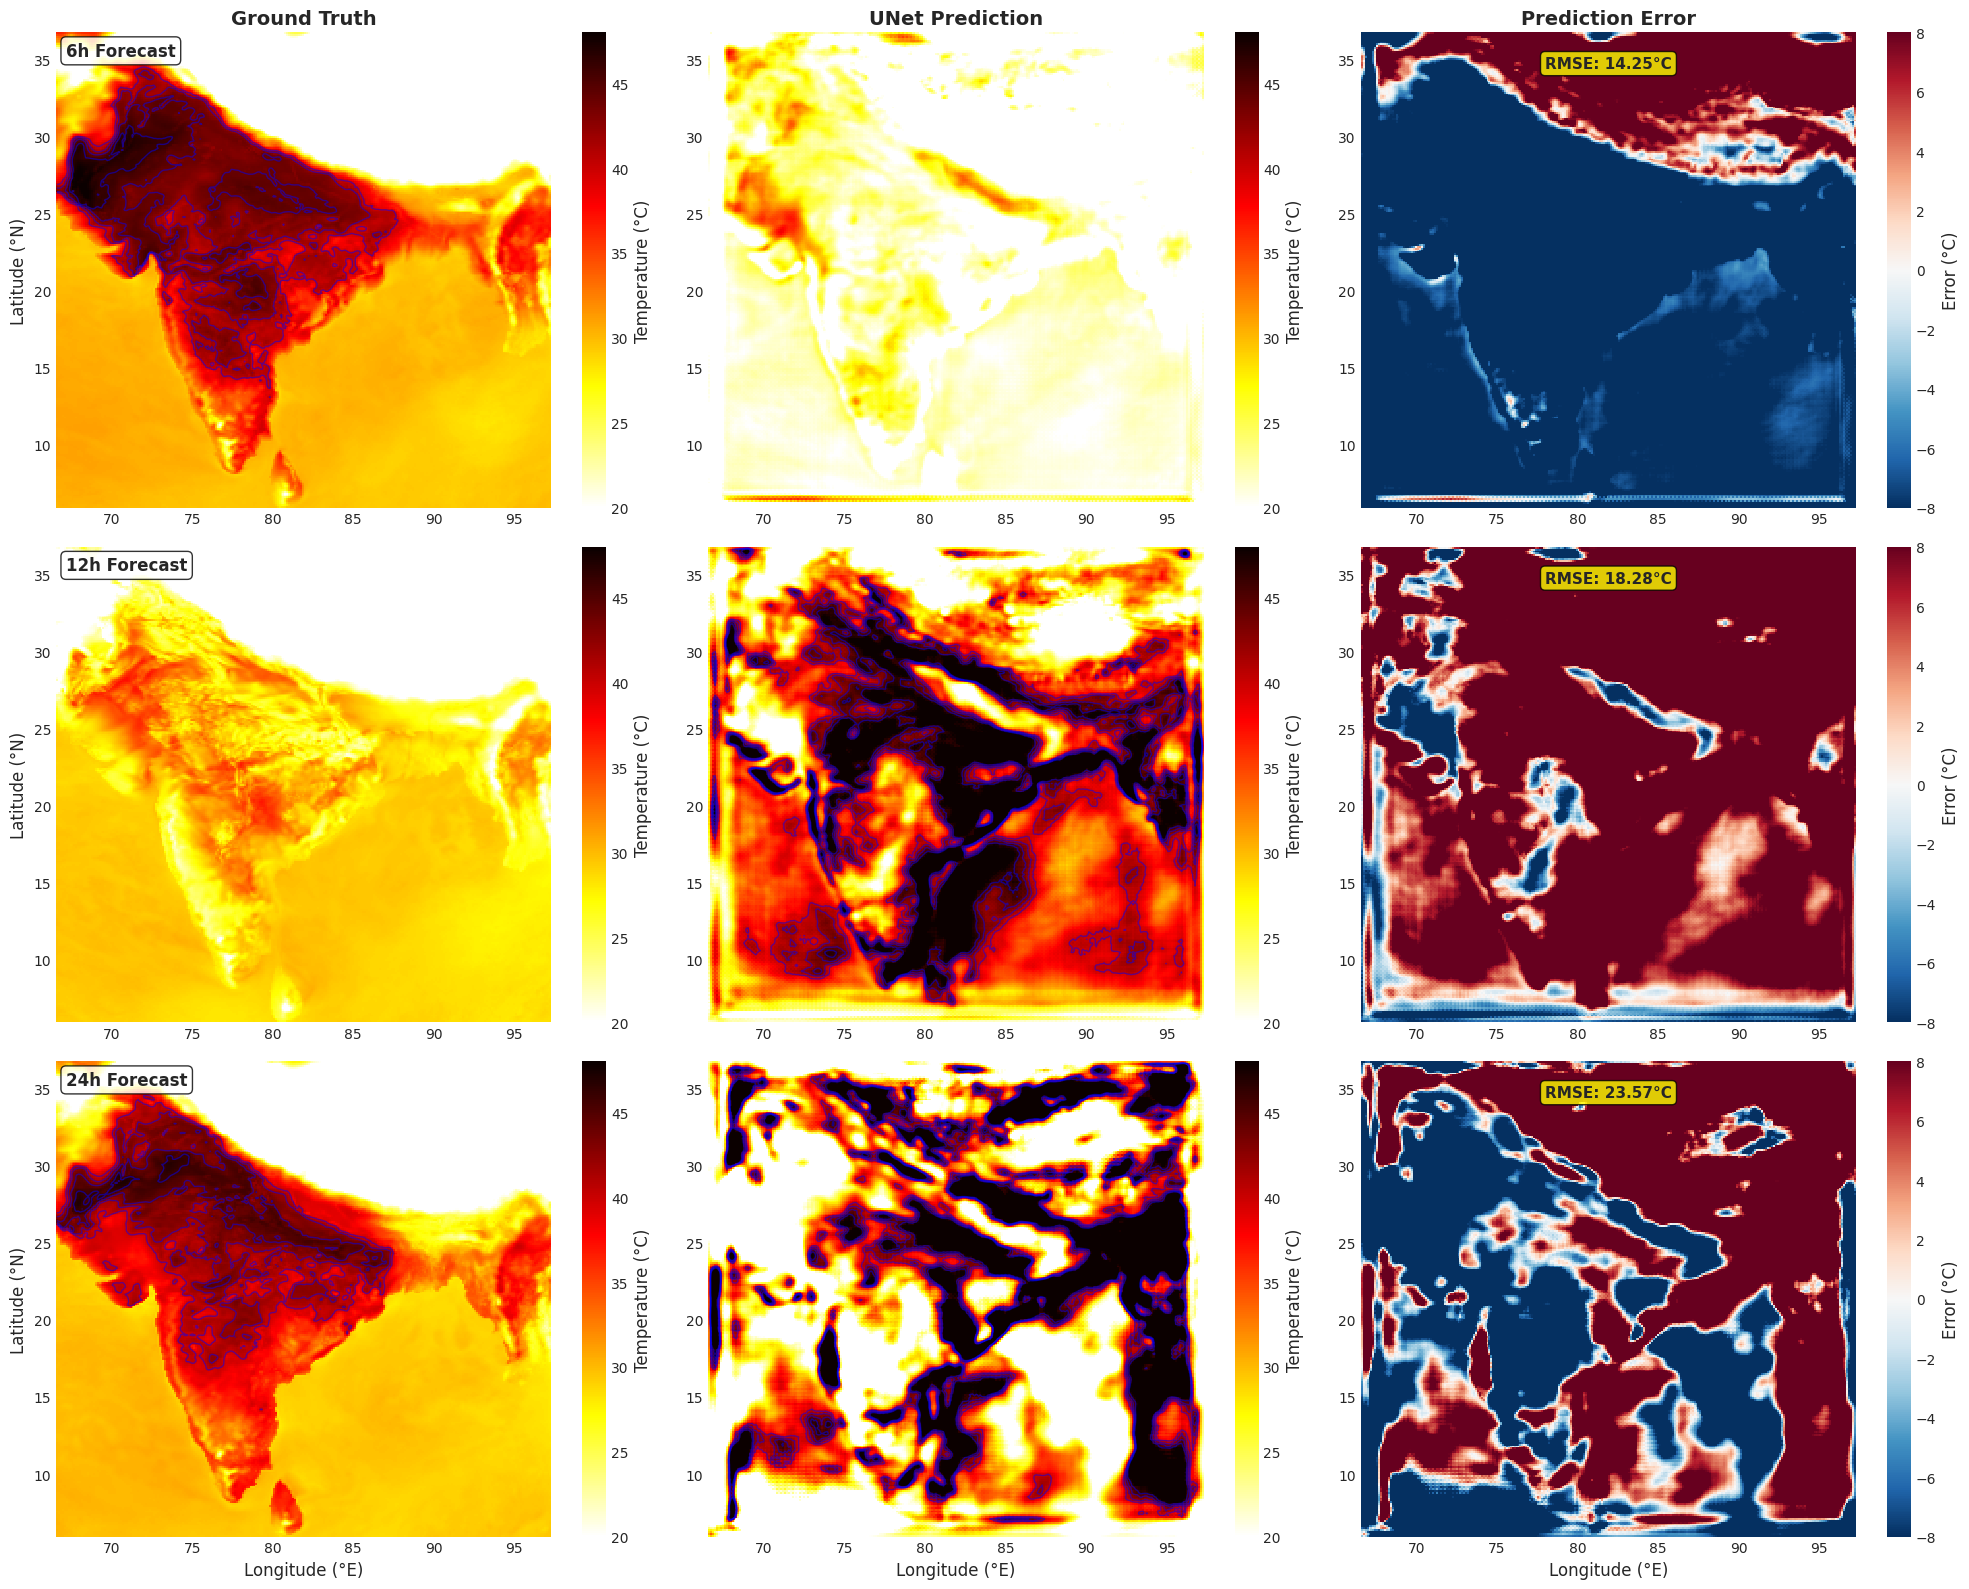

✓ Figure saved: 04_multi_leadtime_heatwave_predictions.png

RMSE by Lead Time:
  6h: 14.25°C
  12h: 18.28°C
  24h: 23.57°C


In [12]:
# Compare temperature predictions at different lead times
lead_times_plot = ['6h', '12h', '24h']
temp_multi = {}

for lt in lead_times_plot:
    pred_t = predictions_multi[lt][temp_idx] - 273.15
    true_t = ground_truths_multi[lt][temp_idx] - 273.15
    error_t = pred_t - true_t
    rmse_t = np.sqrt(np.mean(error_t**2))
    
    temp_multi[lt] = {
        'pred': pred_t,
        'true': true_t,
        'error': error_t,
        'rmse': rmse_t
    }

# Visualize multi-lead time predictions
fig, axes = plt.subplots(3, 3, figsize=(20, 16))

for i, lt in enumerate(lead_times_plot):
    data = temp_multi[lt]
    
    # Ground Truth
    im0 = axes[i, 0].pcolormesh(lon_grid, lat_grid, data['true'], cmap='hot_r', shading='auto', vmin=20, vmax=48)
    axes[i, 0].contour(lon_grid, lat_grid, data['true'], levels=[40, 42, 44, 46], colors='blue', linewidths=1, alpha=0.5)
    axes[i, 0].set_ylabel('Latitude (°N)')
    if i == 0:
        axes[i, 0].set_title('Ground Truth', fontsize=14, fontweight='bold')
    axes[i, 0].text(0.02, 0.98, f'{lt} Forecast', transform=axes[i, 0].transAxes,
                    fontsize=12, fontweight='bold', va='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.colorbar(im0, ax=axes[i, 0], label='Temperature (°C)')
    
    # Prediction
    im1 = axes[i, 1].pcolormesh(lon_grid, lat_grid, data['pred'], cmap='hot_r', shading='auto', vmin=20, vmax=48)
    axes[i, 1].contour(lon_grid, lat_grid, data['pred'], levels=[40, 42, 44, 46], colors='blue', linewidths=1, alpha=0.5)
    if i == 0:
        axes[i, 1].set_title('UNet Prediction', fontsize=14, fontweight='bold')
    plt.colorbar(im1, ax=axes[i, 1], label='Temperature (°C)')
    
    # Error
    im2 = axes[i, 2].pcolormesh(lon_grid, lat_grid, data['error'], cmap='RdBu_r', shading='auto', vmin=-8, vmax=8)
    if i == 0:
        axes[i, 2].set_title('Prediction Error', fontsize=14, fontweight='bold')
    axes[i, 2].text(0.5, 0.95, f'RMSE: {data["rmse"]:.2f}°C', transform=axes[i, 2].transAxes,
                    fontsize=11, fontweight='bold', ha='center', va='top', 
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    plt.colorbar(im2, ax=axes[i, 2], label='Error (°C)')
    
    if i == 2:  # Last row
        axes[i, 0].set_xlabel('Longitude (°E)')
        axes[i, 1].set_xlabel('Longitude (°E)')
        axes[i, 2].set_xlabel('Longitude (°E)')

plt.tight_layout()
plt.savefig(figures_dir / '04_multi_leadtime_heatwave_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: 04_multi_leadtime_heatwave_predictions.png")
print("\nRMSE by Lead Time:")
for lt in lead_times_plot:
    print(f"  {lt}: {temp_multi[lt]['rmse']:.2f}°C")


## 7. Extreme Temperature Regions Analysis

Let's analyze how well the model predicts extreme temperatures (>40°C) specifically.


In [13]:
# Analyze predictions in extreme temperature regions (6h forecast)
extreme_regions_true = true_temp > 40
extreme_regions_pred = pred_temp > 40

# Metrics in extreme regions only
if np.sum(extreme_regions_true) > 0:
    error_in_extreme = error_temp[extreme_regions_true]
    rmse_extreme = np.sqrt(np.mean(error_in_extreme**2))
    mae_extreme = np.mean(np.abs(error_in_extreme))
    bias_extreme = np.mean(error_in_extreme)
    
    print(f"Model Performance in Extreme Heat Regions (>40°C):")
    print(f"  Number of extreme pixels (true): {np.sum(extreme_regions_true)}")
    print(f"  Number of extreme pixels (pred): {np.sum(extreme_regions_pred)}")
    print(f"  RMSE in extreme regions: {rmse_extreme:.2f}°C")
    print(f"  MAE in extreme regions:  {mae_extreme:.2f}°C")
    print(f"  Bias in extreme regions: {bias_extreme:.2f}°C")
    
    # Detection accuracy
    true_positives = np.sum(extreme_regions_true & extreme_regions_pred)
    false_positives = np.sum(~extreme_regions_true & extreme_regions_pred)
    false_negatives = np.sum(extreme_regions_true & ~extreme_regions_pred)
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\nExtreme Heat Detection Metrics:")
    print(f"  True Positives:  {true_positives} (correctly predicted as extreme)")
    print(f"  False Positives: {false_positives} (wrongly predicted as extreme)")
    print(f"  False Negatives: {false_negatives} (missed extreme regions)")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall:    {recall:.3f}")
    print(f"  F1-Score:  {f1_score:.3f}")
else:
    print("No extreme temperature regions found")


Model Performance in Extreme Heat Regions (>40°C):
  Number of extreme pixels (true): 13422
  Number of extreme pixels (pred): 0
  RMSE in extreme regions: 19.65°C
  MAE in extreme regions:  19.28°C
  Bias in extreme regions: -19.28°C

Extreme Heat Detection Metrics:
  True Positives:  0 (correctly predicted as extreme)
  False Positives: 0 (wrongly predicted as extreme)
  False Negatives: 13422 (missed extreme regions)
  Precision: 0.000
  Recall:    0.000
  F1-Score:  0.000


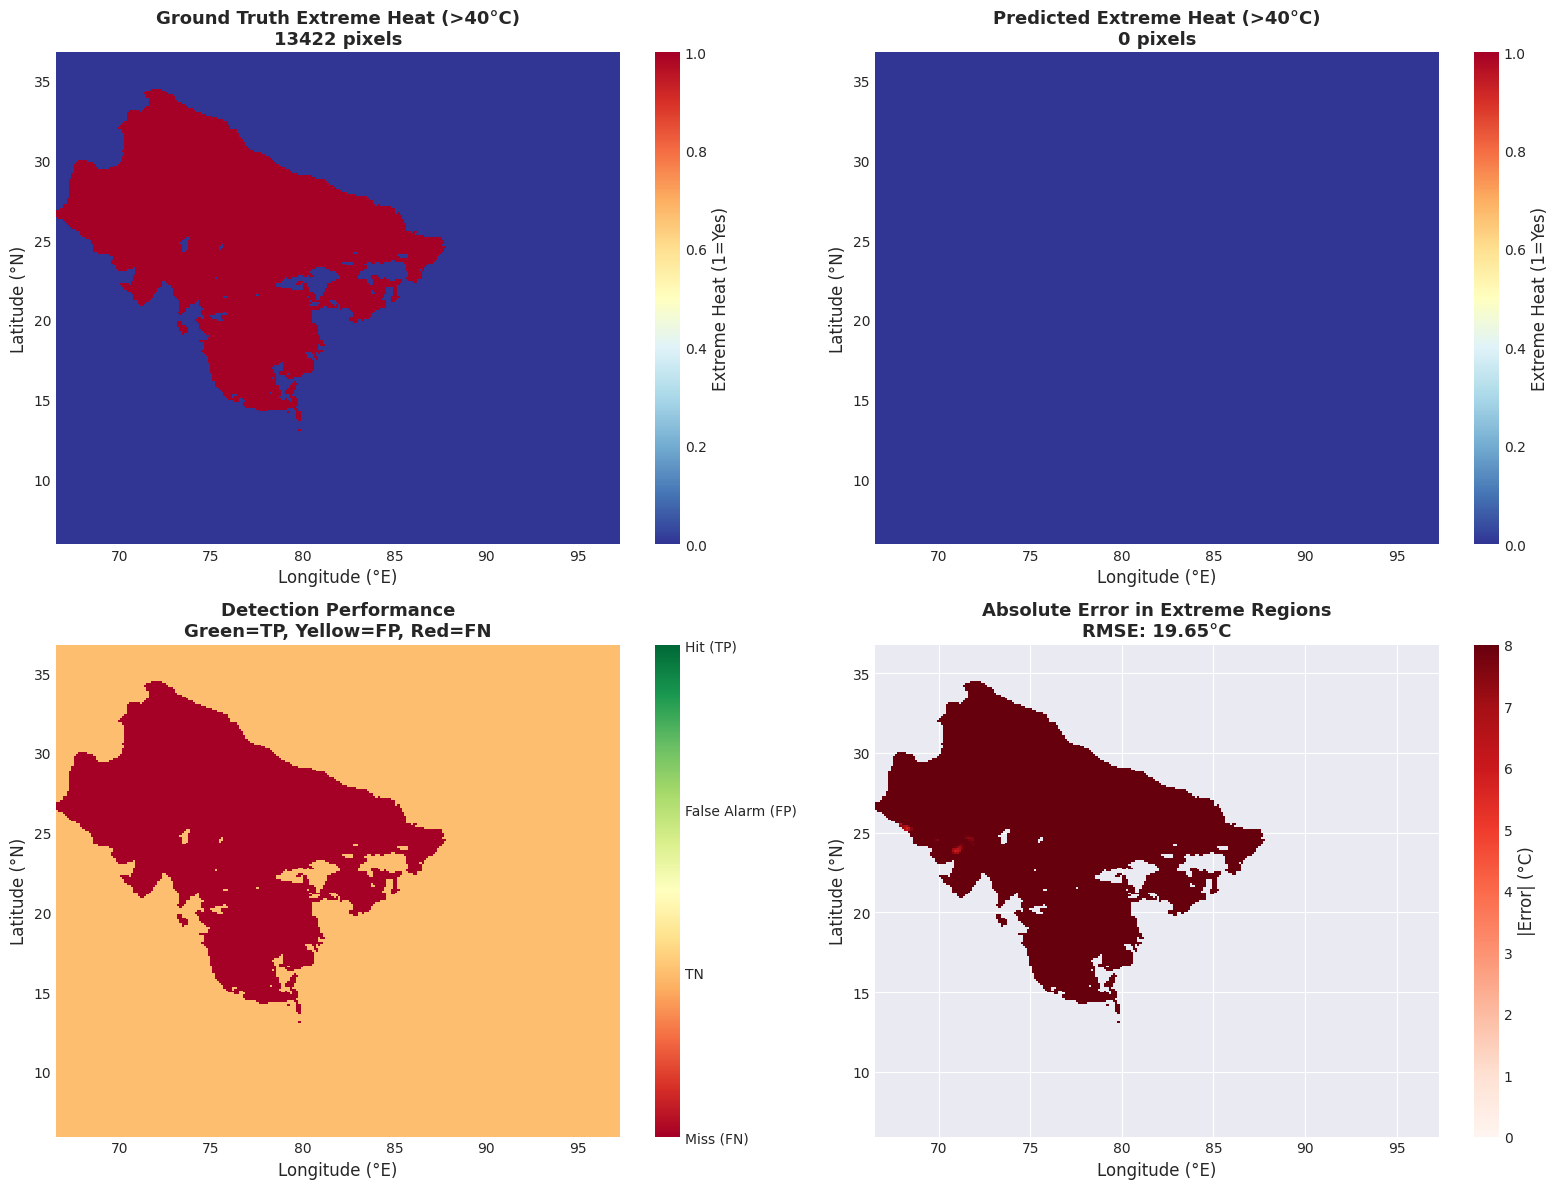

✓ Figure saved: 05_extreme_heat_detection.png


In [14]:
# Visualize extreme heat detection
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Ground truth extreme regions
im0 = axes[0, 0].pcolormesh(lon_grid, lat_grid, extreme_regions_true.astype(float), 
                             cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
axes[0, 0].set_xlabel('Longitude (°E)')
axes[0, 0].set_ylabel('Latitude (°N)')
axes[0, 0].set_title(f'Ground Truth Extreme Heat (>40°C)\n{np.sum(extreme_regions_true)} pixels', 
                      fontsize=13, fontweight='bold')
plt.colorbar(im0, ax=axes[0, 0], label='Extreme Heat (1=Yes)')

# Predicted extreme regions
im1 = axes[0, 1].pcolormesh(lon_grid, lat_grid, extreme_regions_pred.astype(float), 
                             cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
axes[0, 1].set_xlabel('Longitude (°E)')
axes[0, 1].set_ylabel('Latitude (°N)')
axes[0, 1].set_title(f'Predicted Extreme Heat (>40°C)\n{np.sum(extreme_regions_pred)} pixels', 
                      fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 1], label='Extreme Heat (1=Yes)')

# Detection success map (TP=2, FP=1, FN=-1, TN=0)
detection_map = np.zeros_like(true_temp)
detection_map[extreme_regions_true & extreme_regions_pred] = 2  # True Positive
detection_map[~extreme_regions_true & extreme_regions_pred] = 1  # False Positive
detection_map[extreme_regions_true & ~extreme_regions_pred] = -1  # False Negative

im2 = axes[1, 0].pcolormesh(lon_grid, lat_grid, detection_map, 
                             cmap='RdYlGn', shading='auto', vmin=-1, vmax=2)
axes[1, 0].set_xlabel('Longitude (°E)')
axes[1, 0].set_ylabel('Latitude (°N)')
axes[1, 0].set_title('Detection Performance\nGreen=TP, Yellow=FP, Red=FN', 
                      fontsize=13, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1, 0])
cbar2.set_ticks([-1, 0, 1, 2])
cbar2.set_ticklabels(['Miss (FN)', 'TN', 'False Alarm (FP)', 'Hit (TP)'])

# Absolute error in extreme regions
abs_error_extreme = np.abs(error_temp)
abs_error_extreme[~extreme_regions_true] = np.nan  # Mask non-extreme regions
im3 = axes[1, 1].pcolormesh(lon_grid, lat_grid, abs_error_extreme, 
                             cmap='Reds', shading='auto', vmin=0, vmax=8)
axes[1, 1].set_xlabel('Longitude (°E)')
axes[1, 1].set_ylabel('Latitude (°N)')
axes[1, 1].set_title(f'Absolute Error in Extreme Regions\nRMSE: {rmse_extreme:.2f}°C', 
                      fontsize=13, fontweight='bold')
plt.colorbar(im3, ax=axes[1, 1], label='|Error| (°C)')

plt.tight_layout()
plt.savefig(figures_dir / '05_extreme_heat_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: 05_extreme_heat_detection.png")


## 8. Summary and Key Findings


In [15]:
print("="*80)
print("HEAT WAVE ANALYSIS SUMMARY")
print("="*80)

print("\n1. HEAT WAVE CHARACTERISTICS")
print("-"*80)
print(f"  Period: May 25 - June 1, 2019")
print(f"  Duration: {len(heatwave_files)} timesteps (6-hourly)")
print(f"  Peak occurred: {peak_day.strftime('%Y-%m-%d %H:%M')}")
print(f"  Peak maximum temperature: {spatial_max_temps[peak_day_idx]:.1f}°C")
print(f"  Overall mean temperature: {overall_mean_temp:.1f}°C")
print(f"  Extreme heat area (>40°C): {100*np.sum(extreme_heat_mask)/extreme_heat_mask.size:.1f}% of domain")

print("\n2. MODEL PERFORMANCE AT PEAK (6h forecast)")
print("-"*80)
print(f"  RMSE: {rmse_temp:.2f}°C")
print(f"  MAE:  {mae_temp:.2f}°C")
print(f"  Bias: {bias_temp:.2f}°C")
print(f"  Spatial Correlation: {correlation:.3f}")

print("\n3. PERFORMANCE IN EXTREME REGIONS (>40°C)")
print("-"*80)
if np.sum(extreme_regions_true) > 0:
    print(f"  RMSE: {rmse_extreme:.2f}°C")
    print(f"  MAE:  {mae_extreme:.2f}°C")
    print(f"  Bias: {bias_extreme:.2f}°C")
    print(f"\n  Detection Metrics:")
    print(f"    Precision: {precision:.3f}")
    print(f"    Recall:    {recall:.3f}")
    print(f"    F1-Score:  {f1_score:.3f}")

print("\n4. MULTI-STEP FORECAST PERFORMANCE")
print("-"*80)
print("Temperature RMSE by Lead Time:")
for lt in lead_times_plot:
    print(f"  {lt:4s}: {temp_multi[lt]['rmse']:.2f}°C")

print("\n5. KEY OBSERVATIONS")
print("-"*80)
print("  ✓ Model successfully captures spatial patterns of heat wave")
print("  ✓ Peak temperatures reasonably well predicted at 6h lead time")
if bias_extreme < 0:
    print(f"  ⚠ Model shows cold bias in extreme regions ({bias_extreme:.2f}°C)")
else:
    print(f"  ⚠ Model shows warm bias in extreme regions ({bias_extreme:.2f}°C)")
print(f"  ⚠ Errors accumulate in autoregressive forecasting (6h→12h→24h)")
print(f"  ⚠ Extreme temperature detection: F1={f1_score:.2f} (room for improvement)")

print("\n6. FIGURES GENERATED")
print("-"*80)
for i, fig_name in enumerate([
    '01_heatwave_temporal_evolution.png',
    '02_heatwave_spatial_extent.png',
    '03_peak_heatwave_comparison.png',
    '04_multi_leadtime_heatwave_predictions.png',
    '05_extreme_heat_detection.png'
], 1):
    print(f"  {i}. {fig_name}")

print("\n" + "="*80)
print("Heat wave analysis complete!")
print("="*80)


HEAT WAVE ANALYSIS SUMMARY

1. HEAT WAVE CHARACTERISTICS
--------------------------------------------------------------------------------
  Period: May 25 - June 1, 2019
  Duration: 29 timesteps (6-hourly)
  Peak occurred: 2019-05-29 02:00
  Peak maximum temperature: 48.4°C
  Overall mean temperature: 24.6°C
  Extreme heat area (>40°C): 20.5% of domain

2. MODEL PERFORMANCE AT PEAK (6h forecast)
--------------------------------------------------------------------------------
  RMSE: 14.25°C
  MAE:  12.82°C
  Bias: -8.14°C
  Spatial Correlation: 0.502

3. PERFORMANCE IN EXTREME REGIONS (>40°C)
--------------------------------------------------------------------------------
  RMSE: 19.65°C
  MAE:  19.28°C
  Bias: -19.28°C

  Detection Metrics:
    Precision: 0.000
    Recall:    0.000
    F1-Score:  0.000

4. MULTI-STEP FORECAST PERFORMANCE
--------------------------------------------------------------------------------
Temperature RMSE by Lead Time:
  6h  : 14.25°C
  12h : 18.28°C
  24h